# Technical Exercise
## Analysis and comparison of biosignals using different sensors

We have two datasets collected using distinct biomedical devices (`data` folder): `FPdata.xls` and `labchartdata.csv`

### Data Properties:
- `FPdata.xls`:
    - Recorded in a discontinuous manner with nonlinear sampling rate: time stamps correspond to detected start time of a beat;
    - Labeled based on the pressure stage during which the recording was made (Baseline, Stage1, Stage 2). It is not confirmed when the start and end of the FP recording was made relative to pressure chamber stage changes.
- `labchartdata.csv`:
    - Recorded continuously from start to finish with a sampling rate of 1000 Hz.
- Both:
    - Recordings do not necessarily have the same start time;
    - Common metric between 2 datasets: Heart rate (HR).

**Metrics to compare: Cardiac output (CO; `labchartdata.csv`) and Velocity time integral (VTI; `FPdata.xls`).**

In [1]:
import pandas as pd, numpy as np, os, sys
from scipy.interpolate import interp1d
from scipy import signal
import matplotlib.pyplot as plt, seaborn as sns

sys.path.append(os.path.abspath(os.path.join("..")))
from src.loaders import load_data
from src.plotters import plot_HR_by_stage
from src.processors import get_running_time, estimate_sampling_frequency, resample_to_regular_time_base

fp_data, labchart_data = load_data('../data/')

## Exploratory Data Analysis / Pre-Processing
We are told that the `FPdata.xls` was recorded in a discontinuous manner with a non-linear sampling rate, and was labeled by stage. We can visualize this with our helper function. 

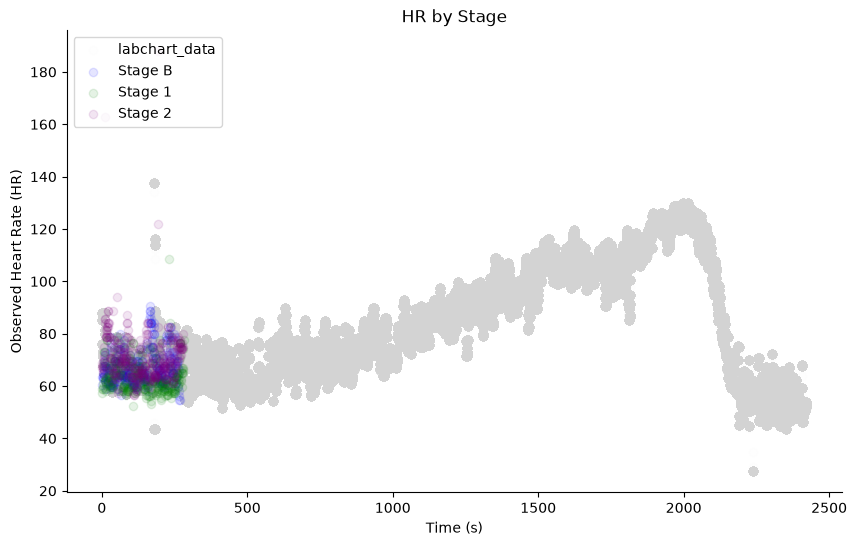

In [2]:
plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Time (s)', hr_col='HR')  

It's clear that we need to fix the timeline for the measurements, as the clock restarts at each stage. It is not clear when the start/end of the recording happened relative to the stage changes, but as a first pass we can concatenate the three stages into one running timeline by offsetting each stage's time by the end of the previous one. 

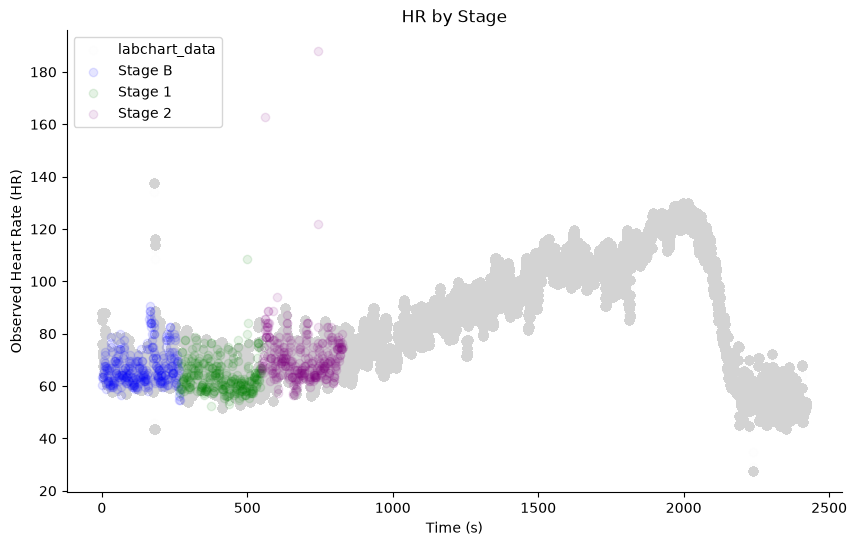

In [3]:
get_running_time(fp_data)
plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Corrected Time (s)', hr_col='HR')

# sanity check
labchart_data.sort_values('TimeSec', inplace=True, ascending=True)
fp_data.sort_values('Corrected Time (s)', inplace=True, ascending=True)

Okay, this looks a little more like it! We may still need to account for some offset between stages, but at least we have a continuous timeline. We also observe some (what look like) erroneous readings, which may need to be excluded for a more accurate alignment. (We can consider outlier filtration on both datasets as a future step.) For now, we'll resample the data to a common time base so we can perform (by stage) cross correlation to determine stage-specific offsets.

In [4]:
# # Adaptive, robust HR outlier filtering using rolling median +/- k*MAD
# def _infer_window_size(n, min_window=25, max_fraction=0.10, scale=4.0):
#     if n <= 0:
#         return 1
#     if n <= min_window:
#         return n
#     upper = max(min_window, int(n * max_fraction))
#     proposed = int(scale * np.sqrt(n))
#     return int(np.clip(proposed, min_window, upper))

# def _rolling_hr_robust_stats(df, hr_col='HR', window_size=None, std_devs=3.5, mad_scale=1.4826):
#     n = len(df)
#     effective_window = _infer_window_size(n) if window_size is None else min(int(window_size), max(n, 1))
#     hr = df[hr_col].astype(float)

#     # Robust center estimate
#     hr_median = hr.rolling(window=effective_window, min_periods=1).median()

#     # Robust spread estimate: MAD, scaled to approximate standard deviation
#     abs_dev = (hr - hr_median).abs()
#     hr_mad = abs_dev.rolling(window=effective_window, min_periods=1).median()
#     hr_scale = mad_scale * hr_mad

#     # Avoid zero-width bands in flat regions
#     positive_scale = hr_scale[hr_scale > 0]
#     fallback_scale = positive_scale.median() if not positive_scale.empty else 1.0
#     hr_scale = hr_scale.where(hr_scale > 0, fallback_scale)

#     lower = hr_median - std_devs * hr_scale
#     upper = hr_median + std_devs * hr_scale
#     mask = hr.between(lower, upper)
#     return hr_median, hr_scale, mask, effective_window

# def filter_hr_outliers(df, hr_col='HR', window_size=None, std_devs=3):
#     hr_center, hr_scale, mask, effective_window = _rolling_hr_robust_stats(
#         df, hr_col=hr_col, window_size=window_size, std_devs=std_devs
#     )
#     filtered_data = df.loc[mask].copy()
#     return filtered_data, hr_center, hr_scale, mask, effective_window

# def _plot_removals(df, time_col, hr_col='HR', window_size=None, std_devs=3, ax=None, title=None):
#     hr_center, hr_scale, mask, effective_window = _rolling_hr_robust_stats(
#         df, hr_col=hr_col, window_size=window_size, std_devs=std_devs
#     )

#     if ax is None:
#         fig, ax = plt.subplots(figsize=(8,3))
#     ax.scatter(df.loc[mask, time_col], df.loc[mask, hr_col], s=1, c='tab:blue', label='kept', alpha=0.6)
#     ax.scatter(df.loc[~mask, time_col], df.loc[~mask, hr_col], s=6, c='red', label='removed', alpha=0.8)
#     ax.set_xlabel(time_col)
#     ax.set_ylabel(hr_col)
#     if title:
#         ax.set_title(f"{title} (MAD, window={effective_window})")
#     sns.despine()
#     ax.legend()

# # Quick visualization of candidate removals for both datasets using auto window sizing
# fig, axes = plt.subplots(1, 2, figsize=(14,4), sharey=True)
# _plot_removals(labchart_data, 'TimeSec', 'HR', window_size=None, std_devs=3, ax=axes[0], title='labchart_data HR')
# _plot_removals(fp_data, 'Corrected Time (s)', 'HR', window_size=None, std_devs=3, ax=axes[1], title='fp_data HR')
# plt.tight_layout()

# std_devs = 3

# filtered_labchart_data, hr_mean, hr_std, mask, labchart_window = filter_hr_outliers(
#     labchart_data, hr_col='HR', window_size=None, std_devs=std_devs
# )

# filtered_fp_data, fp_hr_mean, fp_hr_std, fp_mask, fp_window = filter_hr_outliers(
#     fp_data, hr_col='HR', window_size=None, std_devs=std_devs
# )

# print(f"Auto-selected MAD windows -> labchart: {labchart_window}, fp: {fp_window}")

In [5]:
stage = '2'
stage_fp = fp_data[fp_data['Stage'] == stage].copy()
stage_start = stage_fp['Corrected Time (s)'].min()
stage_end = stage_fp['Corrected Time (s)'].max()
lab_window = labchart_data[(labchart_data['TimeSec'] >= stage_start) & (labchart_data['TimeSec'] <= stage_end)].copy()

# Estimate the native sampling rates and resample both signals to a shared, realistic frequency.
labchart_freq = estimate_sampling_frequency(lab_window, 'TimeSec')
fp_freq = estimate_sampling_frequency(stage_fp, 'Corrected Time (s)')
target_freq = max(1.0, min(10.0, labchart_freq, fp_freq))
sample_period = 1.0 / target_freq

labchart_resampled = resample_to_regular_time_base(
    lab_window, time_col='TimeSec', hr_col='HR', desired_freq=target_freq
)
fp_resampled = resample_to_regular_time_base(
    stage_fp, time_col='Corrected Time (s)', hr_col='HR', desired_freq=target_freq
)

# standardize signals to focus purely on alignment and not amplitude differences
sig1 = labchart_resampled['HR'].astype(float)
sig2 = fp_resampled['HR'].astype(float)
sig1 = (sig1 - sig1.mean()) / sig1.std(ddof=0)
sig2 = (sig2 - sig2.mean()) / sig2.std(ddof=0)


correlation = signal.correlate(sig1, sig2, mode='full')
lags = signal.correlation_lags(len(sig1), len(sig2), mode='full')

# --- 4. Extract Time Sync Offset ---
# Convert lag index to time using the actual resampling period
best_lag_index = np.argmax(correlation)
best_lag = lags[best_lag_index]
calculated_time_delay = best_lag * sample_period

print(f"Stage window: {stage_start:.3f} s to {stage_end:.3f} s")
print(f"Estimated sampling frequencies -> labchart window: {labchart_freq:.3f} Hz, fp stage {stage}: {fp_freq:.3f} Hz")
print(f"Using shared resample frequency: {target_freq:.3f} Hz")
print(f"Calculated Time Delay: {calculated_time_delay:.3f} seconds")
# To sync them: Shift the irregular timeline forward by this calculated delay.
# t_irregular_synced = t_irregular_raw - calculated_time_delay


Stage window: 549.138 s to 827.302 s
Estimated sampling frequencies -> labchart window: 1000.000 Hz, fp stage 2: 1.146 Hz
Using shared resample frequency: 1.146 Hz
Calculated Time Delay: 61.071 seconds


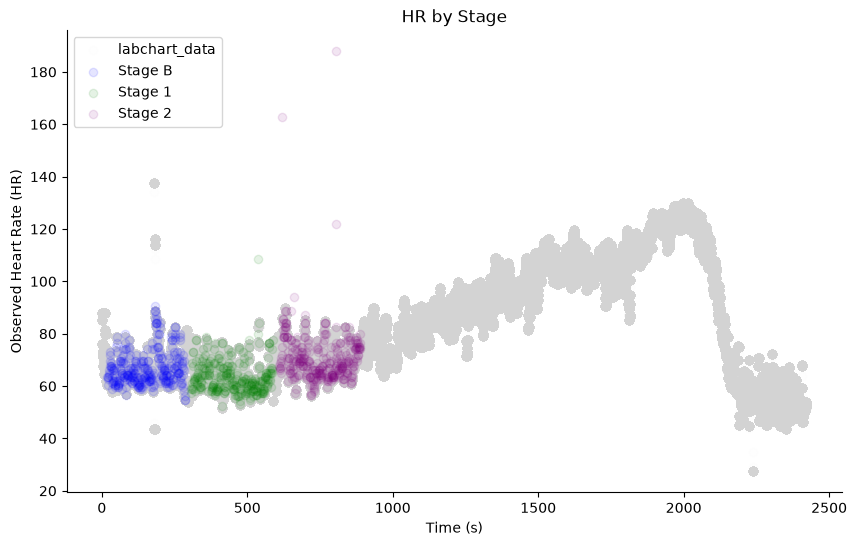

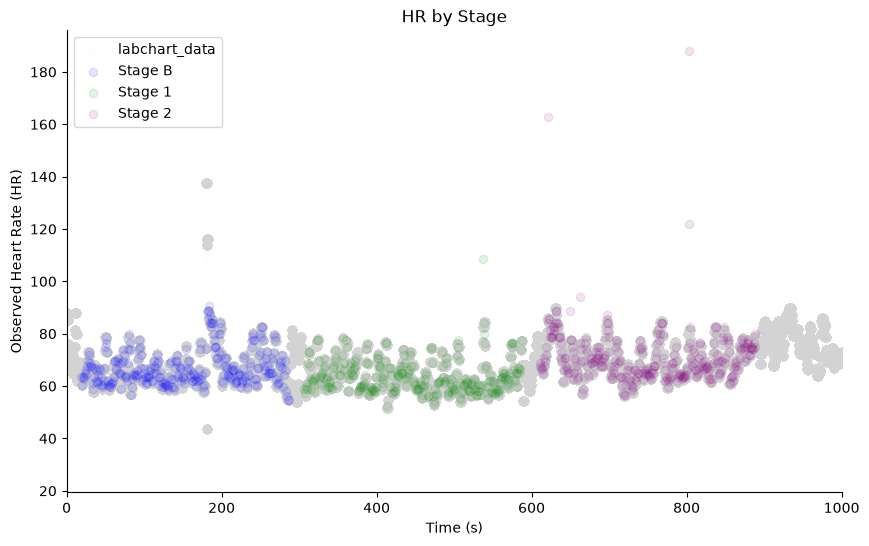

In [6]:
for stage, offset in [('B', 18.432), ('1', 37.859), ('2', 61.071)]:
    mask = fp_data['Stage'] == stage
    fp_data.loc[mask, 'Corrected Time (s)'] = fp_data.loc[mask, 'Corrected Time (s)'] + offset

plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Corrected Time (s)', hr_col='HR')
plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Corrected Time (s)', hr_col='HR', xlim=(0, 1000))    


In [ ]:
# resample the labchart_data to the same time base as the fp_data after time alignment
desired_time_base = fp_data['Corrected Time (s)'].values

labchart_sorted = labchart_data.sort_values('TimeSec').set_index('TimeSec')

labchart_data_resampled = pd.DataFrame({'TimeSec': desired_time_base})

for col in labchart_sorted.columns:
    if pd.api.types.is_numeric_dtype(labchart_sorted[col]):
        labchart_data_resampled[col] = np.interp(
            desired_time_base,
            labchart_sorted.index.to_numpy(),
            labchart_sorted[col].to_numpy()
        )

# # compare the CO from labchart and Vmax VTI Total from fp after time alignment
# # based on the timestamp for the VTI measurement, let's pick the closest CO value from labchart_data for each VTI measurement in fp_data_aligned
# co_values = []
# labchart_data_trimmed = labchart_data[labchart_data['TimeSec'] <= fp_data_aligned['Corrected Time (s)'].max()]

# for vti_time in fp_data_aligned['Corrected Time (s)']:
#     closest_co_time = labchart_data_trimmed.iloc[(labchart_data_trimmed['TimeSec'] - vti_time).abs().argsort()[:1]]['TimeSec'].values[0]
#     closest_co_value = labchart_data_trimmed.iloc[(labchart_data_trimmed['TimeSec'] - vti_time).abs().argsort()[:1]]['CO'].values[0]
#     # print(f"VTI Time: {vti_time:.3f} s, Closest CO Time: {closest_co_time:.3f} s, CO Value: {closest_co_value:.2f} L/min")
#     co_values.append((vti_time, closest_co_time, closest_co_value))

# # store into a dataframe for better visualization
# co_comparison_df = pd.DataFrame(co_values, columns=['VTI Time (s)', 'Closest CO Time (s)', 'CO Value (L/min)'])
# print(co_comparison_df)    

In [8]:
# # compute the correlation between the CO values and the Vmax VTI Total values from fp_data_aligned
# # assuming the Vmax VTI Total values are in a column named 'Vmax VTI Total' in fp_data_aligned
# if 'Vmax VTI Total' in fp_data_aligned.columns:
#     vti_values = fp_data_aligned['Vmax VTI Total'].values
#     co_values = co_comparison_df['CO Value (L/min)'].values

#     # Ensure both arrays are of the same length for correlation
#     min_length = min(len(vti_values), len(co_values))
#     vti_values = vti_values[:min_length]
#     co_values = co_values[:min_length]

#     correlation_co_vti = np.corrcoef(co_values, vti_values)[0, 1]
#     print(f"Correlation between CO and Vmax VTI Total: {correlation_co_vti:.3f}")